# Exploratory Data Analysis: Dynamic Pricing Anomaly Detection

This notebook explores the synthetic pricing dataset to understand:
1. **Price distributions** across categories, regions, and time
2. **Temporal patterns** — hourly, daily, weekly seasonality
3. **Supply-demand dynamics** and their relationship to surge pricing
4. **Anomaly characteristics** — what do injected anomalies look like?
5. **Feature correlations** — which features are most informative for detection?

These insights directly inform the anomaly detection design decisions.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('Set2')

print('Setup complete.')

Setup complete.


## 1. Generate & Load Data

In [2]:
from src.data_generator import DynamicPricingDataGenerator

generator = DynamicPricingDataGenerator()
end_date = datetime(2024, 9, 15, 12, 0)
start_date = end_date - timedelta(days=90)
pricing_df, anomaly_df = generator.generate(start_date=start_date, end_date=end_date, seed=42)

pricing_df['timestamp'] = pd.to_datetime(pricing_df['timestamp'])
pricing_df['hour'] = pricing_df['timestamp'].dt.hour
pricing_df['day_of_week'] = pricing_df['timestamp'].dt.day_name()
pricing_df['is_weekend'] = pricing_df['timestamp'].dt.dayofweek >= 5
pricing_df['date'] = pricing_df['timestamp'].dt.date

normal_df = pricing_df[pricing_df['is_anomaly'] == False].copy()
anom_df = pricing_df[pricing_df['is_anomaly'] == True].copy()

print(f'Total events: {len(pricing_df):,}')
print(f'Normal events: {len(normal_df):,} ({len(normal_df)/len(pricing_df)*100:.1f}%)')
print(f'Anomalous events: {len(anom_df):,} ({len(anom_df)/len(pricing_df)*100:.1f}%)')
print(f'Date range: {pricing_df["timestamp"].min()} to {pricing_df["timestamp"].max()}')
print(f'Categories: {sorted(pricing_df["category"].unique())}')
print(f'Regions: {sorted(pricing_df["region"].unique())}')

2026-04-18 17:14:53.036 | INFO     | src.data_generator:generate:441 - Generating data from 2024-06-17 12:00:00 to 2024-09-15 12:00:00 (90 days, ~50 events/hour, 5 categories)
2026-04-18 17:15:01.711 | INFO     | src.data_generator:generate:515 - Generated 108403 pricing events, 13684 injected anomalies (12.62%)


Total events: 108,403
Normal events: 94,719 (87.4%)
Anomalous events: 13,684 (12.6%)
Date range: 2024-06-17 12:00:44.289669 to 2024-09-15 11:58:35.272118
Categories: [np.str_('delivery_food'), np.str_('delivery_grocery'), np.str_('ride_pool'), np.str_('ride_premium'), np.str_('ride_standard')]
Regions: [np.str_('airport'), np.str_('downtown'), np.str_('industrial'), np.str_('suburbs'), np.str_('university')]


In [3]:
pricing_df.head(10)

,timestamp,category,base_price,surge_multiplier,final_price,demand_level,supply_level,distance_miles,duration_minutes,region,is_anomaly,anomaly_type,event_id,hour,day_of_week,is_weekend,date
0,2024-06-17 12:00:44.289669,ride_standard,12.50,3.9246,113.59,0.8509,0.2945,7.62,29.2,airport,False,None,0,12,Monday,False,2024-06-17
1,2024-06-17 12:00:50.170636,ride_standard,12.50,2.3415,61.98,0.6591,0.5796,6.85,23.0,suburbs,False,None,1,12,Monday,False,2024-06-17
2,2024-06-17 12:01:04.212422,delivery_food,5.99,3.2416,32.65,0.8660,0.3617,1.86,7.4,downtown,False,None,2,12,Monday,False,2024-06-17
3,2024-06-17 12:02:14.685202,ride_standard,12.50,4.0018,114.74,1.0000,0.3014,7.29,29.7,airport,False,None,3,12,Monday,False,2024-06-17
4,2024-06-17 12:02:24.544678,ride_pool,8.00,3.9307,65.81,0.7854,0.4754,4.41,13.8,suburbs,False,None,4,12,Monday,False,2024-06-17
5,2024-06-17 12:03:29.889870,delivery_grocery,7.99,1.8221,38.71,0.6642,0.5836,5.92,24.6,suburbs,False,None,5,12,Monday,False,2024-06-17
6,2024-06-17 12:05:03.999556,delivery_food,5.99,2.9569,62.35,1.0000,0.5631,6.54,29.0,airport,False,None,6,12,Monday,False,2024-06-17
7,2024-06-17 12:05:40.080005,delivery_food,5.99,3.3070,59.68,0.8128,0.3092,4.88,24.8,university,False,None,7,12,Monday,False,2024-06-17
8,2024-06-17 12:06:30.872668,delivery_food,5.99,2.1550,31.05,0.7891,0.6754,3.87,15.1,university,False,None,8,12,Monday,False,2024-06-17
9,2024-06-17 12:07:01.572837,delivery_food,5.99,3.0463,44.24,0.9757,0.5089,3.32,18.2,downtown,False,None,9,12,Monday,False,2024-06-17


## 2. Price Distributions by Category

**Key question:** Do categories have distinct enough distributions for per-category detection?

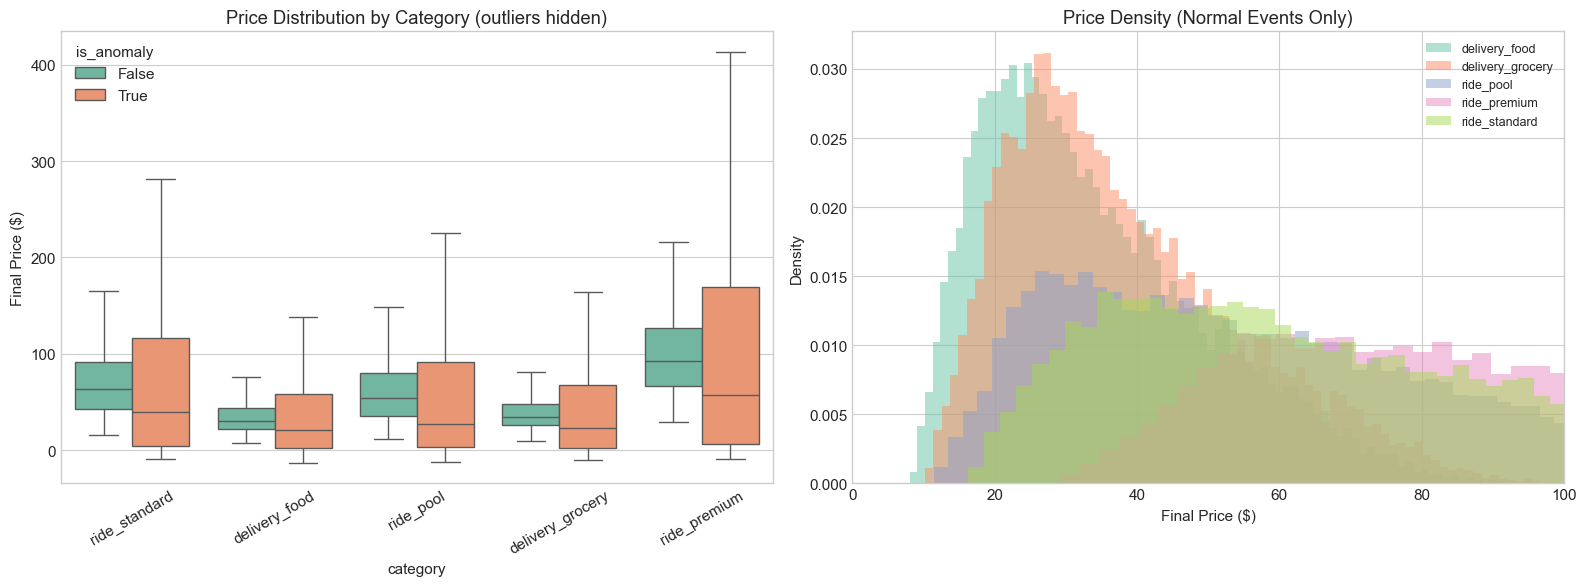


--- Normal Price Statistics ---


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
delivery_food,19020.0,34.17,15.58,8.09,21.97,30.94,43.80,93.74
delivery_grocery,18889.0,38.32,16.30,10.18,25.87,34.87,48.19,105.03
ride_pool,19214.0,60.75,31.24,11.50,35.15,54.64,80.66,173.59
ride_premium,18751.0,99.78,40.98,29.22,66.72,92.81,126.51,249.32
ride_standard,18845.0,70.09,33.75,16.23,43.14,63.13,92.04,198.04


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot — all data
sns.boxplot(data=pricing_df, x='category', y='final_price', hue='is_anomaly',
            ax=axes[0], showfliers=False)
axes[0].set_title('Price Distribution by Category (outliers hidden)')
axes[0].set_ylabel('Final Price ($)')
axes[0].tick_params(axis='x', rotation=30)

# Histogram — normal data only (log scale)
for cat in sorted(normal_df['category'].unique()):
    cat_data = normal_df[normal_df['category'] == cat]['final_price']
    axes[1].hist(cat_data, bins=80, alpha=0.5, label=cat, density=True)
axes[1].set_title('Price Density (Normal Events Only)')
axes[1].set_xlabel('Final Price ($)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Summary statistics
print('\n--- Normal Price Statistics ---')
display(normal_df.groupby('category')['final_price'].describe().round(2))

**Insight:** Categories have distinct price ranges — ride_premium is 2-3x ride_pool. This is why we use **per-category baselines** in the statistical and contextual detectors. A global Z-score would miss anomalies in low-price categories because they'd be within the premium range.

## 3. Temporal Patterns

**Key question:** How strong are hourly/weekly patterns? This determines whether contextual detection adds value.

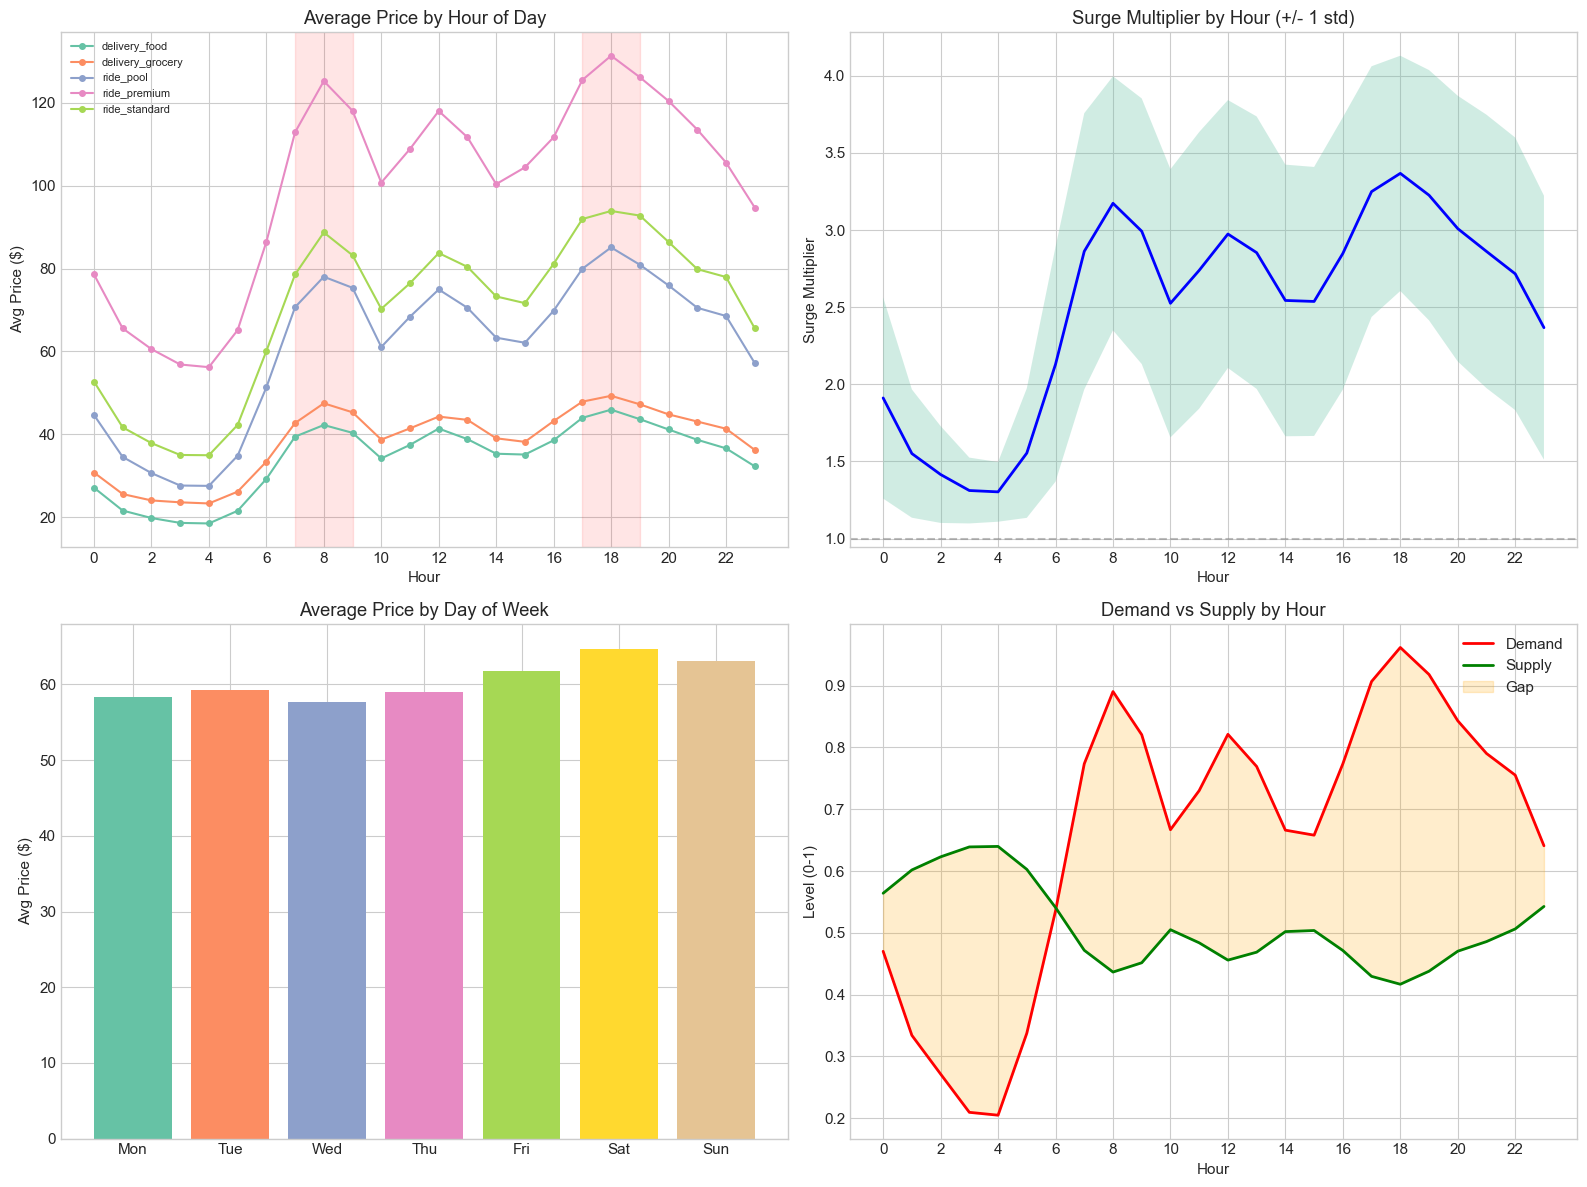

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Hourly price pattern
hourly = normal_df.groupby(['hour', 'category'])['final_price'].mean().reset_index()
for cat in sorted(hourly['category'].unique()):
    cat_data = hourly[hourly['category'] == cat]
    axes[0, 0].plot(cat_data['hour'], cat_data['final_price'], marker='o', label=cat, markersize=4)
axes[0, 0].set_title('Average Price by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Avg Price ($)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_xticks(range(0, 24, 2))
# Mark rush hours
for rh in [(7, 9), (17, 19)]:
    axes[0, 0].axvspan(rh[0], rh[1], alpha=0.1, color='red', label='Rush hour' if rh[0]==7 else None)

# Hourly surge pattern
hourly_surge = normal_df.groupby('hour')['surge_multiplier'].agg(['mean', 'std']).reset_index()
axes[0, 1].fill_between(hourly_surge['hour'],
                         hourly_surge['mean'] - hourly_surge['std'],
                         hourly_surge['mean'] + hourly_surge['std'], alpha=0.3)
axes[0, 1].plot(hourly_surge['hour'], hourly_surge['mean'], 'b-', linewidth=2)
axes[0, 1].set_title('Surge Multiplier by Hour (+/- 1 std)')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Surge Multiplier')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Day-of-week pattern
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = normal_df.groupby('day_of_week')['final_price'].mean().reindex(dow_order)
axes[1, 0].bar(range(7), dow_data.values, color=sns.color_palette('Set2', 7))
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].set_title('Average Price by Day of Week')
axes[1, 0].set_ylabel('Avg Price ($)')

# Demand-supply by hour
hourly_ds = normal_df.groupby('hour')[['demand_level', 'supply_level']].mean().reset_index()
axes[1, 1].plot(hourly_ds['hour'], hourly_ds['demand_level'], 'r-', linewidth=2, label='Demand')
axes[1, 1].plot(hourly_ds['hour'], hourly_ds['supply_level'], 'g-', linewidth=2, label='Supply')
axes[1, 1].fill_between(hourly_ds['hour'], hourly_ds['demand_level'], hourly_ds['supply_level'],
                         alpha=0.2, color='orange', label='Gap')
axes[1, 1].set_title('Demand vs Supply by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Level (0-1)')
axes[1, 1].legend()
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

**Insight:** Strong hourly patterns — prices peak during 7-9am and 5-7pm rush hours when demand outstrips supply. Weekend prices are ~15-30% higher. This justifies the **contextual detector** which builds baselines per (category, hour_block, weekday/weekend). A $40 ride at 6pm is normal; the same price at 3am is suspicious.

## 4. Regional Variation

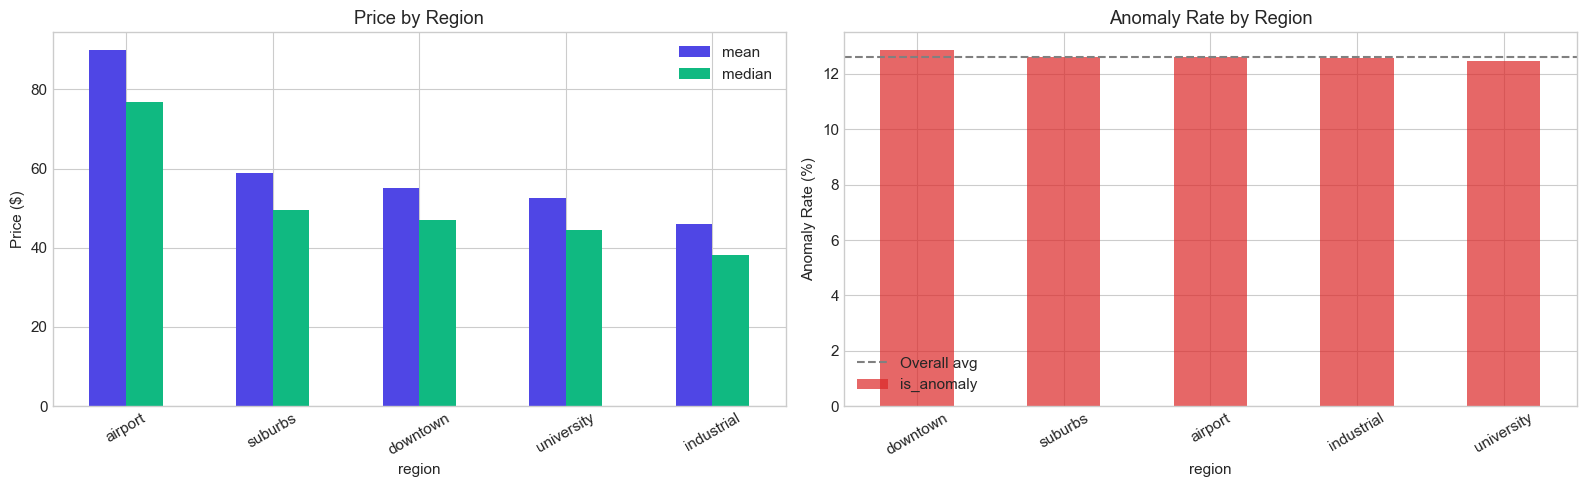


--- Region Statistics (Normal Events) ---


,count,avg_price,avg_distance,avg_surge,avg_demand
region,,,,,
airport,19048,89.92,9.59,2.88,0.79
downtown,18886,55.04,3.53,2.81,0.76
industrial,18905,46.03,5.79,1.92,0.46
suburbs,19008,58.76,6.68,2.29,0.58
university,18872,52.65,3.95,2.59,0.68


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Price by region
region_price = normal_df.groupby('region')['final_price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)
region_price[['mean', 'median']].plot(kind='bar', ax=axes[0], color=['#4F46E5', '#10B981'])
axes[0].set_title('Price by Region')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=30)

# Anomaly rate by region
region_anom = pricing_df.groupby('region')['is_anomaly'].mean().sort_values(ascending=False) * 100
region_anom.plot(kind='bar', ax=axes[1], color='#DC2626', alpha=0.7)
axes[1].set_title('Anomaly Rate by Region')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(y=pricing_df['is_anomaly'].mean()*100, color='gray', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n--- Region Statistics (Normal Events) ---')
display(normal_df.groupby('region').agg(
    count=('final_price', 'count'),
    avg_price=('final_price', 'mean'),
    avg_distance=('distance_miles', 'mean'),
    avg_surge=('surge_multiplier', 'mean'),
    avg_demand=('demand_level', 'mean'),
).round(2))

## 5. Anomaly Analysis

**Key question:** What do the injected anomalies look like? Which types are hardest to detect?

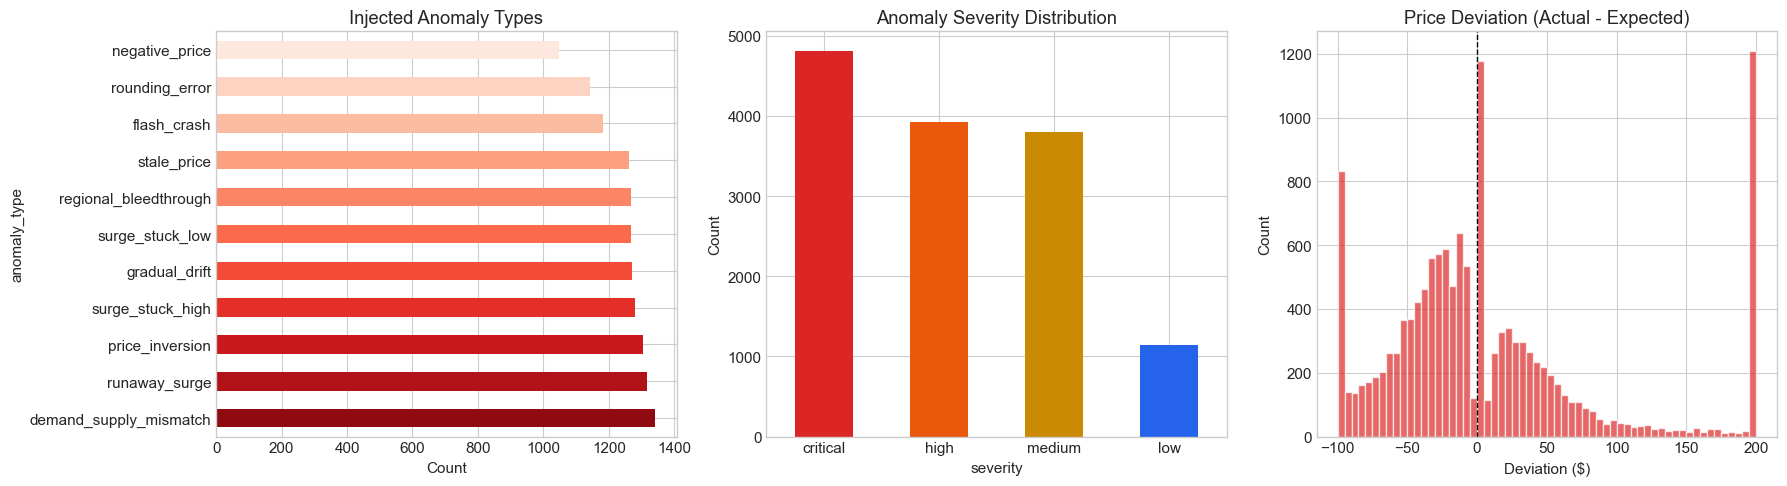

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Anomaly type distribution
if not anomaly_df.empty:
    type_counts = anomaly_df['anomaly_type'].value_counts()
    type_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Reds_r', len(type_counts)))
    axes[0].set_title('Injected Anomaly Types')
    axes[0].set_xlabel('Count')

# Anomaly severity distribution
if not anomaly_df.empty:
    sev_counts = anomaly_df['severity'].value_counts()
    colors = {'critical': '#DC2626', 'high': '#EA580C', 'medium': '#CA8A04', 'low': '#2563EB'}
    sev_counts.plot(kind='bar', ax=axes[1], color=[colors.get(s, '#6B7280') for s in sev_counts.index])
    axes[1].set_title('Anomaly Severity Distribution')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)

# Price difference: anomaly vs expected
if not anomaly_df.empty and 'expected_price' in anomaly_df.columns:
    anomaly_df['price_deviation'] = anomaly_df['actual_price'] - anomaly_df['expected_price']
    axes[2].hist(anomaly_df['price_deviation'].clip(-100, 200), bins=60, color='#DC2626', alpha=0.7, edgecolor='white')
    axes[2].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[2].set_title('Price Deviation (Actual - Expected)')
    axes[2].set_xlabel('Deviation ($)')
    axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

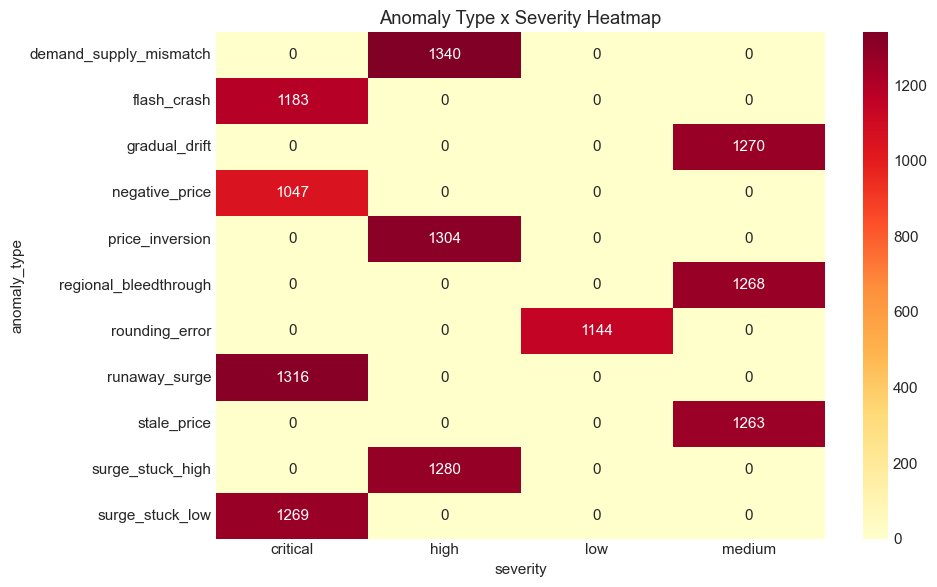


Anomaly Type Counts:


anomaly_type
demand_supply_mismatch    1340
runaway_surge             1316
price_inversion           1304
surge_stuck_high          1280
gradual_drift             1270
surge_stuck_low           1269
regional_bleedthrough     1268
stale_price               1263
flash_crash               1183
rounding_error            1144
negative_price            1047
Name: count, dtype: int64

In [9]:
# Anomaly type vs severity crosstab
if not anomaly_df.empty:
    ct = pd.crosstab(anomaly_df['anomaly_type'], anomaly_df['severity'])
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Anomaly Type x Severity Heatmap')
    plt.tight_layout()
    plt.show()

print('\nAnomaly Type Counts:')
display(anomaly_df['anomaly_type'].value_counts())

## 6. Anomaly Clustering Patterns

Real-world pricing bugs don't produce isolated anomalies — they corrupt consecutive transactions. Our generator simulates this with burst clusters of 5-20 events.

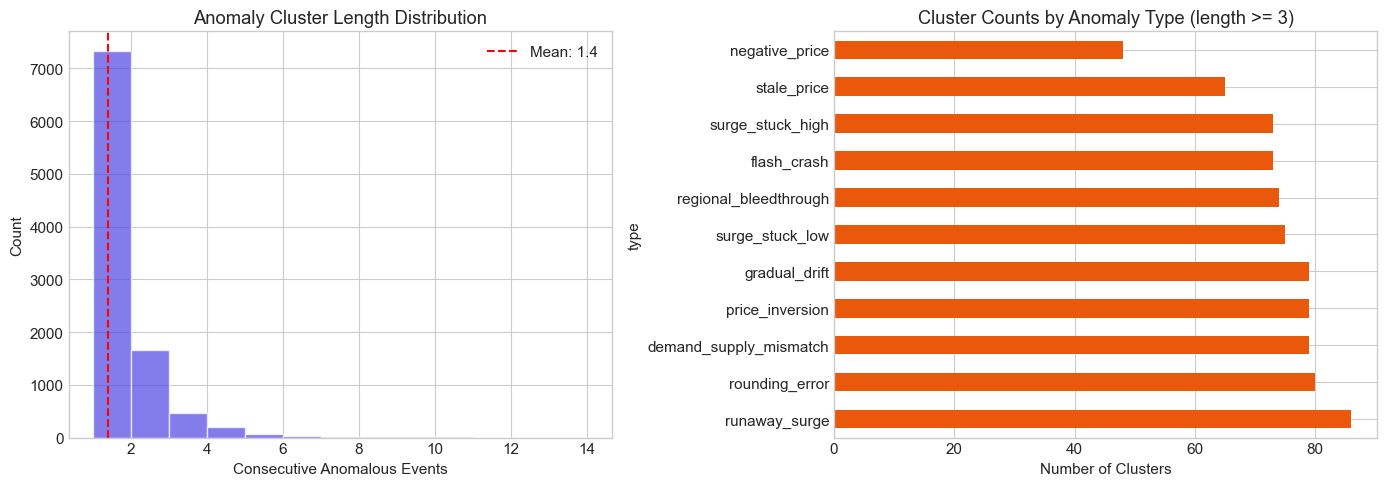


Total anomaly runs: 9799
Single events: 7336
Clusters (2+): 2463
Large clusters (5+): 140
Max cluster length: 13


In [10]:
# Find runs of consecutive anomalies
anom_flags = pricing_df['is_anomaly'].values
runs = []
current_run = 0
current_type = None
for i, flag in enumerate(anom_flags):
    if flag:
        current_run += 1
        if pricing_df.iloc[i]['anomaly_type']:
            current_type = pricing_df.iloc[i]['anomaly_type']
    else:
        if current_run > 0:
            runs.append({'length': current_run, 'type': current_type})
        current_run = 0
        current_type = None
if current_run > 0:
    runs.append({'length': current_run, 'type': current_type})

runs_df = pd.DataFrame(runs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not runs_df.empty:
    axes[0].hist(runs_df['length'], bins=range(1, runs_df['length'].max()+2),
                 color='#4F46E5', alpha=0.7, edgecolor='white')
    axes[0].set_title('Anomaly Cluster Length Distribution')
    axes[0].set_xlabel('Consecutive Anomalous Events')
    axes[0].set_ylabel('Count')
    axes[0].axvline(x=runs_df['length'].mean(), color='red', linestyle='--',
                    label=f'Mean: {runs_df["length"].mean():.1f}')
    axes[0].legend()

    # Top cluster types
    top_types = runs_df[runs_df['length'] >= 3].groupby('type')['length'].agg(['count', 'mean']).sort_values('count', ascending=False)
    if not top_types.empty:
        top_types['count'].plot(kind='barh', ax=axes[1], color='#EA580C')
        axes[1].set_title('Cluster Counts by Anomaly Type (length >= 3)')
        axes[1].set_xlabel('Number of Clusters')

plt.tight_layout()
plt.show()

print(f'\nTotal anomaly runs: {len(runs_df)}')
print(f'Single events: {(runs_df["length"]==1).sum()}')
print(f'Clusters (2+): {(runs_df["length"]>=2).sum()}')
print(f'Large clusters (5+): {(runs_df["length"]>=5).sum()}')
print(f'Max cluster length: {runs_df["length"].max()}')

**Insight:** Anomaly clustering is critical — a detector that catches the first event in a burst and misses the rest is still useful (you only need one alert to trigger investigation). But recall metrics should account for cluster-level detection, not just event-level.

## 7. Feature Correlations & Engineered Features

Which features best separate anomalies from normal events?

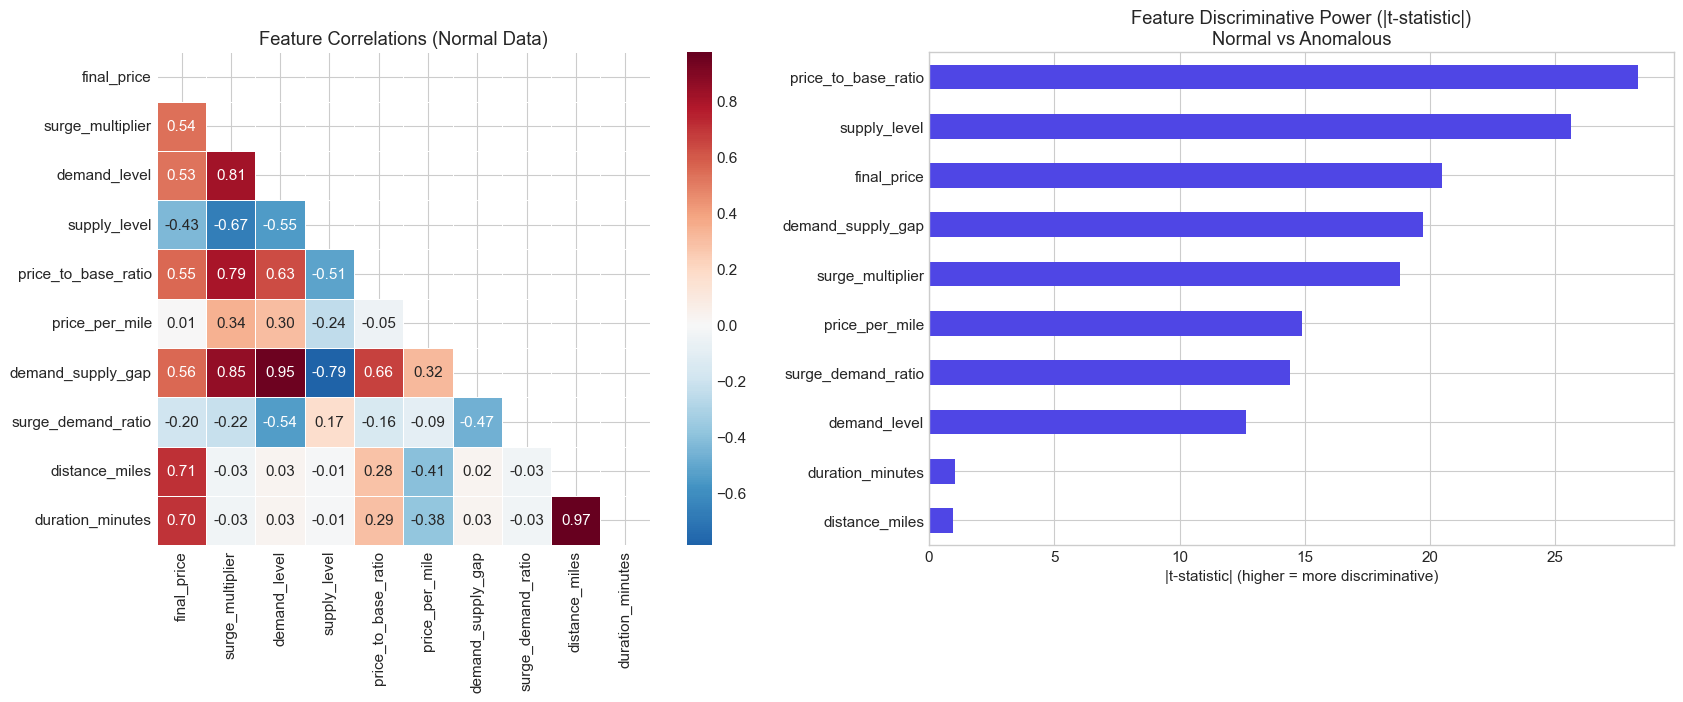

In [11]:
# Engineer the same features used by the detectors
feat_df = pricing_df.copy()
feat_df['price_to_base_ratio'] = feat_df['final_price'] / feat_df['base_price'].clip(lower=0.01)
feat_df['price_per_mile'] = feat_df['final_price'] / feat_df['distance_miles'].clip(lower=0.1)
feat_df['demand_supply_gap'] = feat_df['demand_level'] - feat_df['supply_level']
feat_df['surge_demand_ratio'] = feat_df['surge_multiplier'] / feat_df['demand_level'].clip(lower=0.01)
feat_df['log_price'] = np.log1p(feat_df['final_price'].clip(lower=0))
feat_df['speed_implied'] = feat_df['distance_miles'] / (feat_df['duration_minutes'].clip(lower=1) / 60)

feature_cols = ['final_price', 'surge_multiplier', 'demand_level', 'supply_level',
                'price_to_base_ratio', 'price_per_mile', 'demand_supply_gap',
                'surge_demand_ratio', 'distance_miles', 'duration_minutes']

# Correlation matrix (normal data)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = feat_df[feat_df['is_anomaly']==False][feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Feature Correlations (Normal Data)')

# Feature importance: t-test between normal and anomalous
from scipy import stats as sp_stats

importances = {}
for col in feature_cols:
    normal_vals = feat_df.loc[feat_df['is_anomaly']==False, col].dropna()
    anom_vals = feat_df.loc[feat_df['is_anomaly']==True, col].dropna()
    if len(anom_vals) > 10 and len(normal_vals) > 10:
        t_stat, p_val = sp_stats.ttest_ind(normal_vals, anom_vals, equal_var=False)
        importances[col] = abs(t_stat)

imp_df = pd.DataFrame.from_dict(importances, orient='index', columns=['t_statistic']).sort_values('t_statistic', ascending=True)
imp_df.plot(kind='barh', ax=axes[1], legend=False, color='#4F46E5')
axes[1].set_title('Feature Discriminative Power (|t-statistic|)\nNormal vs Anomalous')
axes[1].set_xlabel('|t-statistic| (higher = more discriminative)')

plt.tight_layout()
plt.show()

**Insight:** `surge_multiplier`, `price_to_base_ratio`, and `surge_demand_ratio` are the most discriminative features — they measure whether the pricing algorithm's output matches the market conditions. This validates our feature engineering choices for the Isolation Forest.

## 8. Scatter: Anomalies in Feature Space

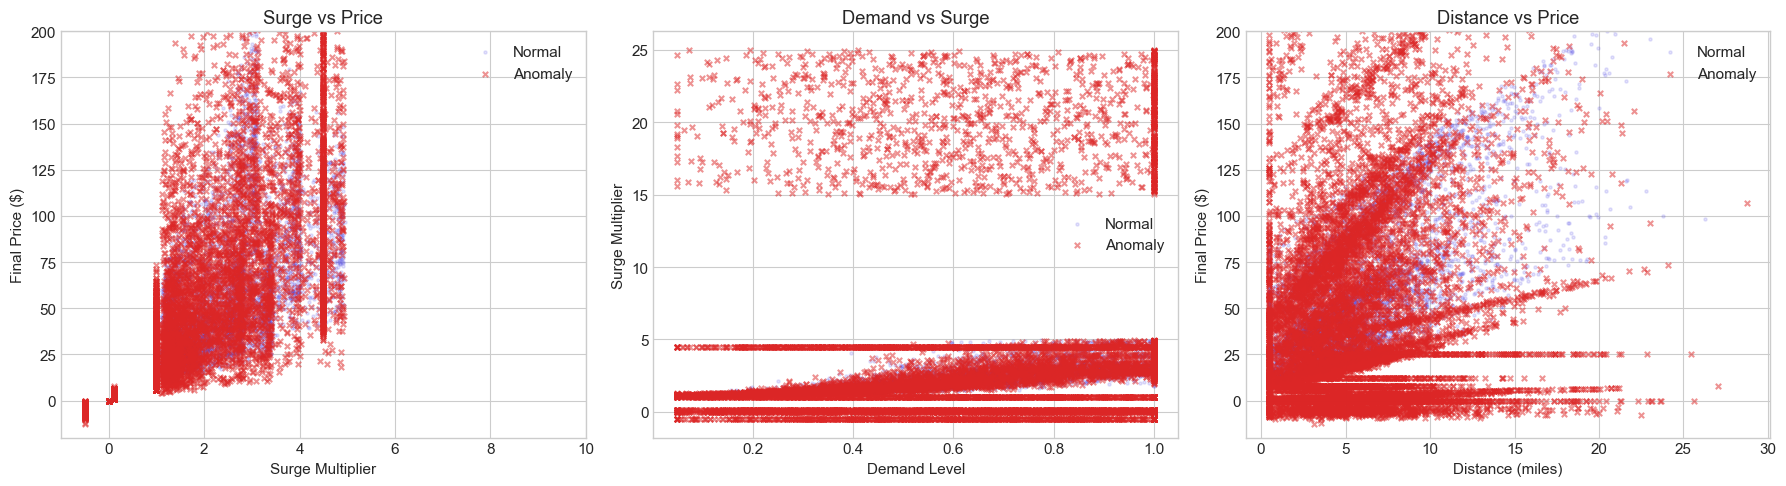

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subsample normal for visibility
n_show = min(5000, len(normal_df))
normal_sample = normal_df.sample(n=n_show, random_state=42)

# Surge vs Price
axes[0].scatter(normal_sample['surge_multiplier'], normal_sample['final_price'],
                alpha=0.15, s=5, c='#4F46E5', label='Normal')
axes[0].scatter(anom_df['surge_multiplier'], anom_df['final_price'],
                alpha=0.5, s=15, c='#DC2626', label='Anomaly', marker='x')
axes[0].set_xlabel('Surge Multiplier')
axes[0].set_ylabel('Final Price ($)')
axes[0].set_title('Surge vs Price')
axes[0].legend()
axes[0].set_xlim(-1, 10)
axes[0].set_ylim(-20, 200)

# Demand vs Surge (colored by anomaly)
axes[1].scatter(normal_sample['demand_level'], normal_sample['surge_multiplier'],
                alpha=0.15, s=5, c='#4F46E5', label='Normal')
axes[1].scatter(anom_df['demand_level'], anom_df['surge_multiplier'],
                alpha=0.5, s=15, c='#DC2626', label='Anomaly', marker='x')
axes[1].set_xlabel('Demand Level')
axes[1].set_ylabel('Surge Multiplier')
axes[1].set_title('Demand vs Surge')
axes[1].legend()

# Distance vs Price
axes[2].scatter(normal_sample['distance_miles'], normal_sample['final_price'],
                alpha=0.15, s=5, c='#4F46E5', label='Normal')
axes[2].scatter(anom_df['distance_miles'], anom_df['final_price'],
                alpha=0.5, s=15, c='#DC2626', label='Anomaly', marker='x')
axes[2].set_xlabel('Distance (miles)')
axes[2].set_ylabel('Final Price ($)')
axes[2].set_title('Distance vs Price')
axes[2].legend()
axes[2].set_ylim(-20, 200)

plt.tight_layout()
plt.show()

## 9. Heavy Tails & Distribution Shape

This is why we use MAD-based detection alongside Z-score — pricing data has heavy tails.

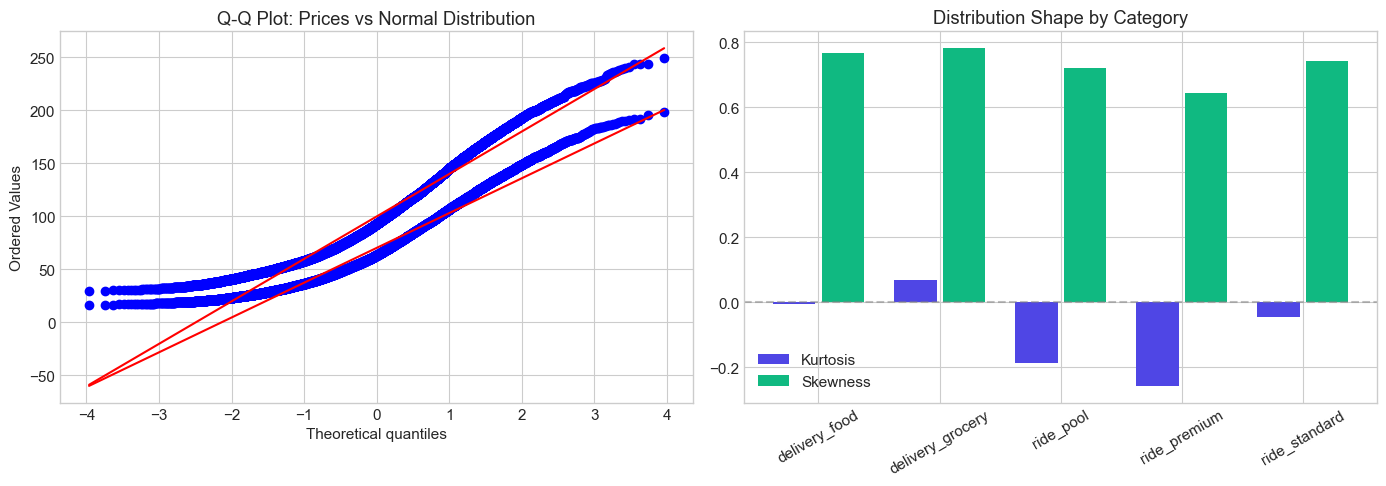


Distribution shape metrics:


,kurtosis,skewness
category,,
delivery_food,-0.007,0.766
delivery_grocery,0.068,0.782
ride_pool,-0.187,0.721
ride_premium,-0.257,0.643
ride_standard,-0.046,0.744



Positive kurtosis = heavier tails than normal (leptokurtic)
Positive skewness = right-skewed (long tail of high prices)
This is why MAD-based detection is critical — Z-score assumes normality.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
from scipy.stats import probplot
for cat in ['ride_standard', 'ride_premium']:
    cat_prices = normal_df[normal_df['category'] == cat]['final_price'].values
    probplot(cat_prices, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Prices vs Normal Distribution')
axes[0].get_lines()[0].set_label('ride_standard')

# Kurtosis by category
from scipy.stats import kurtosis, skew
kurt_data = []
for cat in sorted(normal_df['category'].unique()):
    prices = normal_df[normal_df['category'] == cat]['final_price']
    kurt_data.append({
        'category': cat,
        'kurtosis': kurtosis(prices),
        'skewness': skew(prices),
    })
kurt_df = pd.DataFrame(kurt_data)

x = range(len(kurt_df))
axes[1].bar([i-0.2 for i in x], kurt_df['kurtosis'], width=0.35, label='Kurtosis', color='#4F46E5')
axes[1].bar([i+0.2 for i in x], kurt_df['skewness'], width=0.35, label='Skewness', color='#10B981')
axes[1].set_xticks(x)
axes[1].set_xticklabels(kurt_df['category'], rotation=30)
axes[1].set_title('Distribution Shape by Category')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nDistribution shape metrics:')
display(kurt_df.set_index('category').round(3))
print('\nPositive kurtosis = heavier tails than normal (leptokurtic)')
print('Positive skewness = right-skewed (long tail of high prices)')
print('This is why MAD-based detection is critical — Z-score assumes normality.')

## 10. Summary of Key EDA Findings

| Finding | Implication for Detection |
|---|---|
| **Distinct per-category distributions** | Must use per-category baselines, not global |
| **Strong hourly/weekly seasonality** | Contextual detection adds value — same price can be normal/anomalous depending on time |
| **Heavy-tailed distributions** | Z-score alone is insufficient; MAD and IQR methods needed |
| **Anomaly clustering** | Detection at cluster-level matters more than event-level recall |
| **Surge-demand ratio is most discriminative** | Feature engineering is crucial — raw price alone won't catch all anomaly types |
| **Regional variation** | Anomaly rates are roughly uniform across regions, but absolute price levels differ |
| **11 anomaly types with varying severity** | No single method catches all types — ensemble approach is justified |